In [3]:
#---------------Essential libraries------------------ 
import pandas as pd  
import numpy as np
#--------------visulation libraries----------------
import matplotlib.pyplot as plt 
%matplotlib inline 
import seaborn as sns
#-------------sklean essentials-----------
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression,Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV

## **step 1. load dataset**
---
Goal : Predict California house prices using housing features such as income, average rooms, population, and location. 


In [4]:
housing= fetch_california_housing(as_frame=True)

df=pd.DataFrame(data=housing.data,columns=housing.feature_names)
print(f'dataset shape: {df.shape[0]} rows x {df.shape[1]} columns')
df['Price']=housing.target # adding target variable to df 
df.head()

dataset shape: 20640 rows x 8 columns


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## **step 2. Explore and understand the dataset** 
**we inspect:**
 -Data types 
 -Missing values 
 -Statistical summery 
 -Duplicate record

In [5]:
print("==Data types & non-null counts===")
df.info()

==Data types & non-null counts===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [6]:
print(df.isnull().sum())
print('=='*30)
print(f"total number of missing values: {df.isnull().sum().sum()}")
print('--'*30)

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Price         0
dtype: int64
total number of missing values: 0
------------------------------------------------------------


In [7]:
print('-'*30)
print("== Statistical report==")
print('-'*30)
df.describe()


------------------------------
== Statistical report==
------------------------------


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [8]:
print(df.duplicated().sum() )#missing duplicate check

0


## **step 3. Feature engineering :**

In [9]:
#can i calculate cost of one room ? no because of dataleakage (as price is target variable)
# we don't know the price before the model predicts 
df["Rooms_Per_Household"]=df['AveRooms']/df['AveOccup']
df['BedRooms_Per_Rooms']=df['AveBedrms']/df['AveRooms']
df["population_per_household"]=df["Population"]/df["AveOccup"]
print(' new feature created :      |')
print("--"*20)
print(' 1.-> Rooms per household : |')
print(' 2.-> Bed Rooms per Room  : |')
print(' 3.-> poputaion per house : |')

 new feature created :      |
----------------------------------------
 1.-> Rooms per household : |
 2.-> Bed Rooms per Room  : |
 3.-> poputaion per house : |


## **step 4. visulise the dataset**

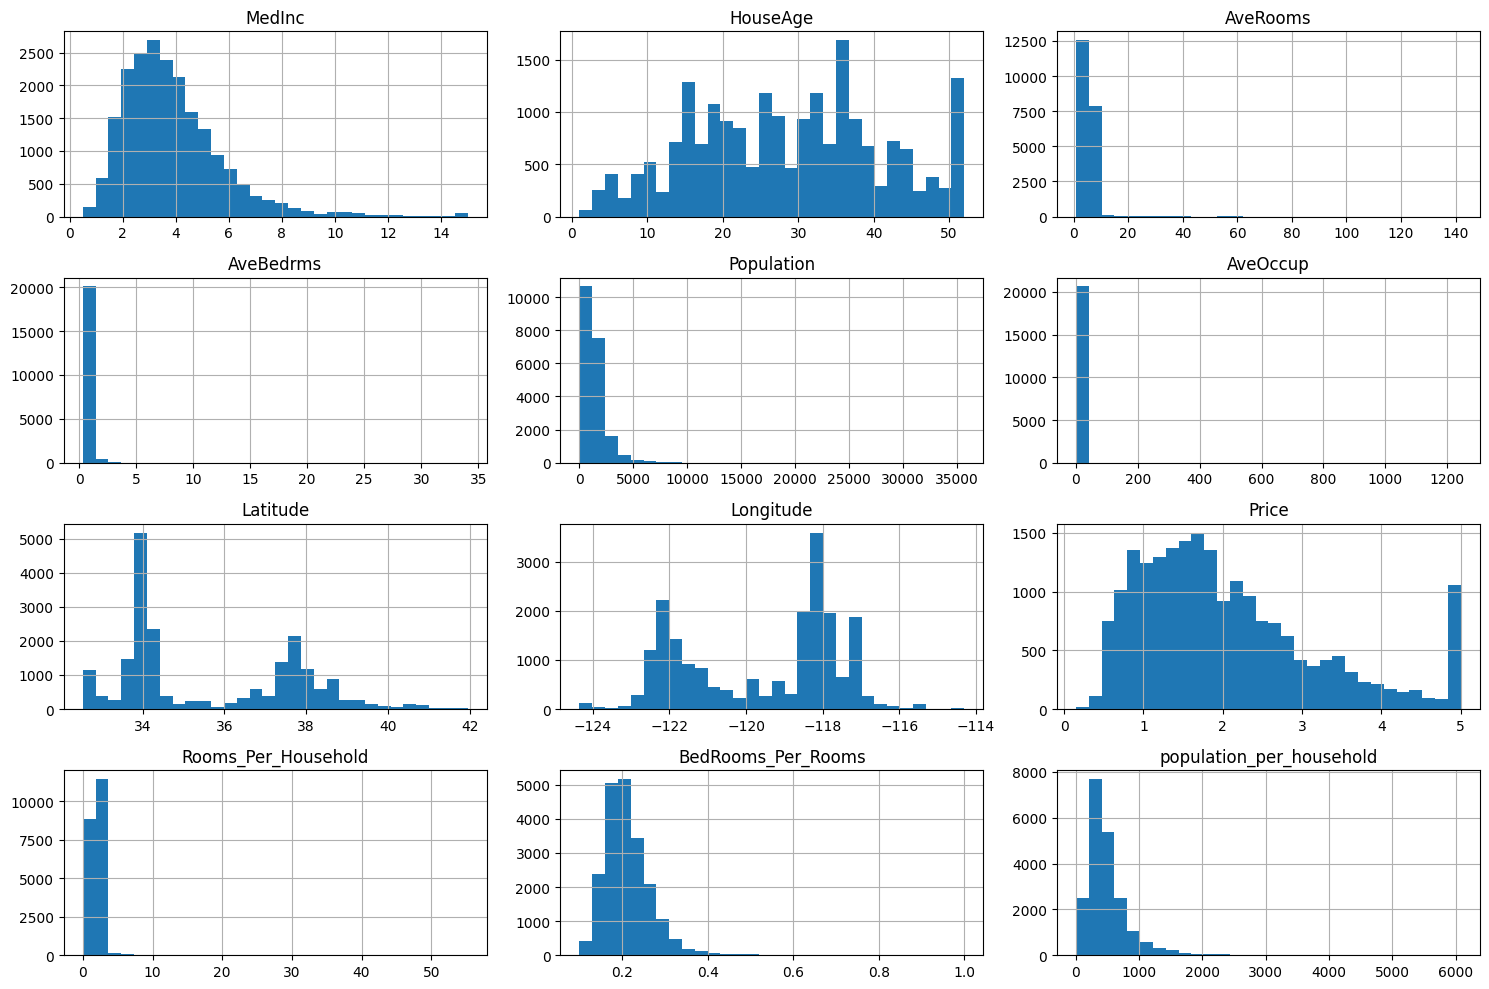

In [10]:
df.hist(figsize=(15,10),bins=30)
plt.tight_layout()
plt.show()



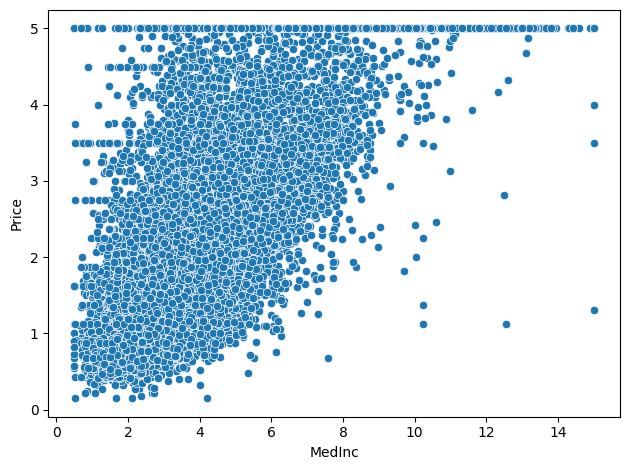

In [11]:
sns.scatterplot(
    x='MedInc',
    y='Price',
    data=df,
    )
plt.tight_layout()
plt.show()


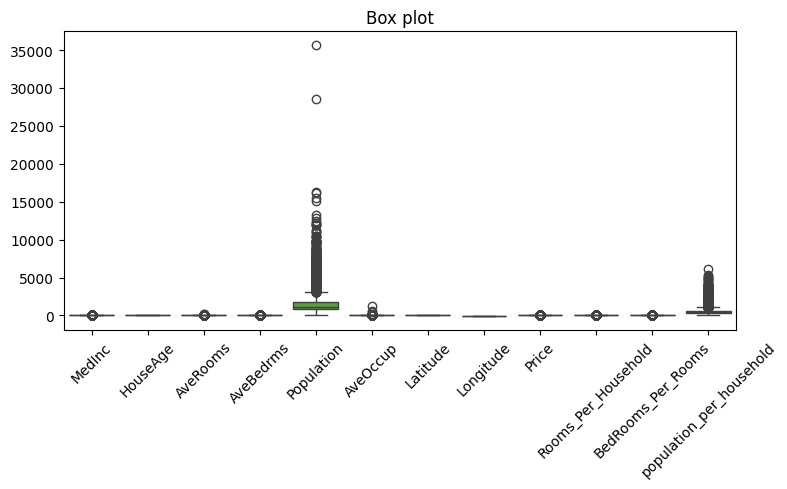

In [12]:
#box plot show outliers :
plt.figure(figsize=(8,5))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.title('Box plot')
plt.tight_layout()
plt.show()


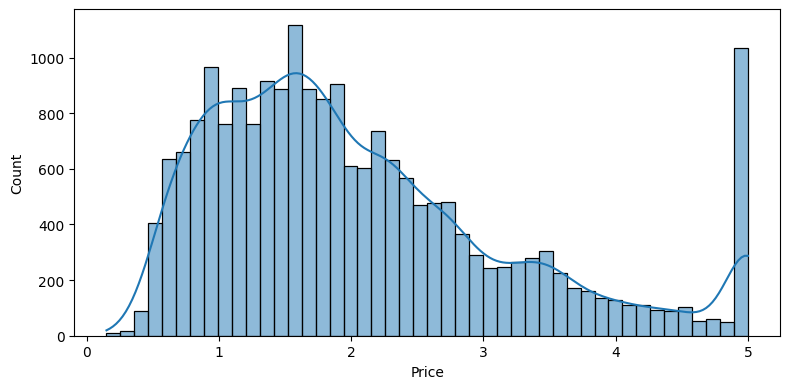

In [13]:
plt.figure(figsize=(8,4))
sns.histplot(df['Price'], kde=True)
plt.tight_layout()
plt.show()

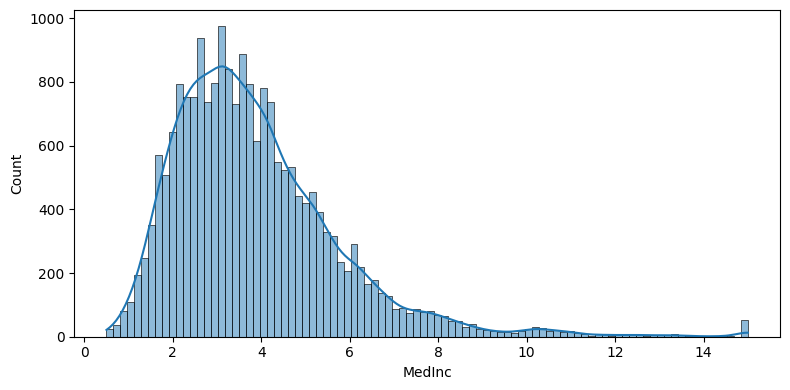

In [14]:
plt.figure(figsize=(8,4))
sns.histplot(df['MedInc'], kde=True)
plt.tight_layout()
plt.show()

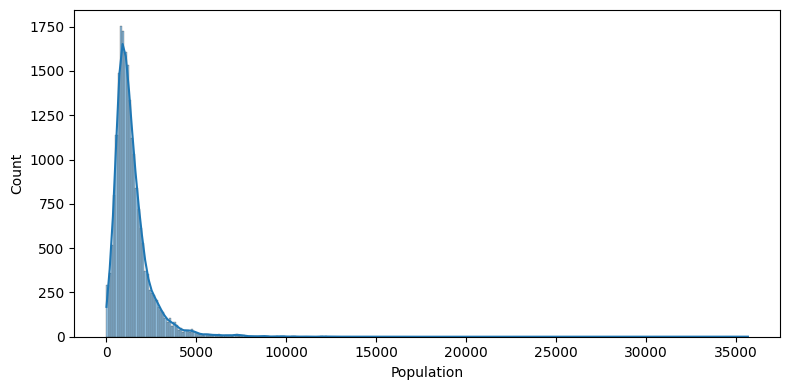

In [15]:
plt.figure(figsize=(8,4))
sns.histplot(df['Population'], kde=True)

plt.tight_layout()
plt.show()

*Here, we can clearly see population has do many outliers*

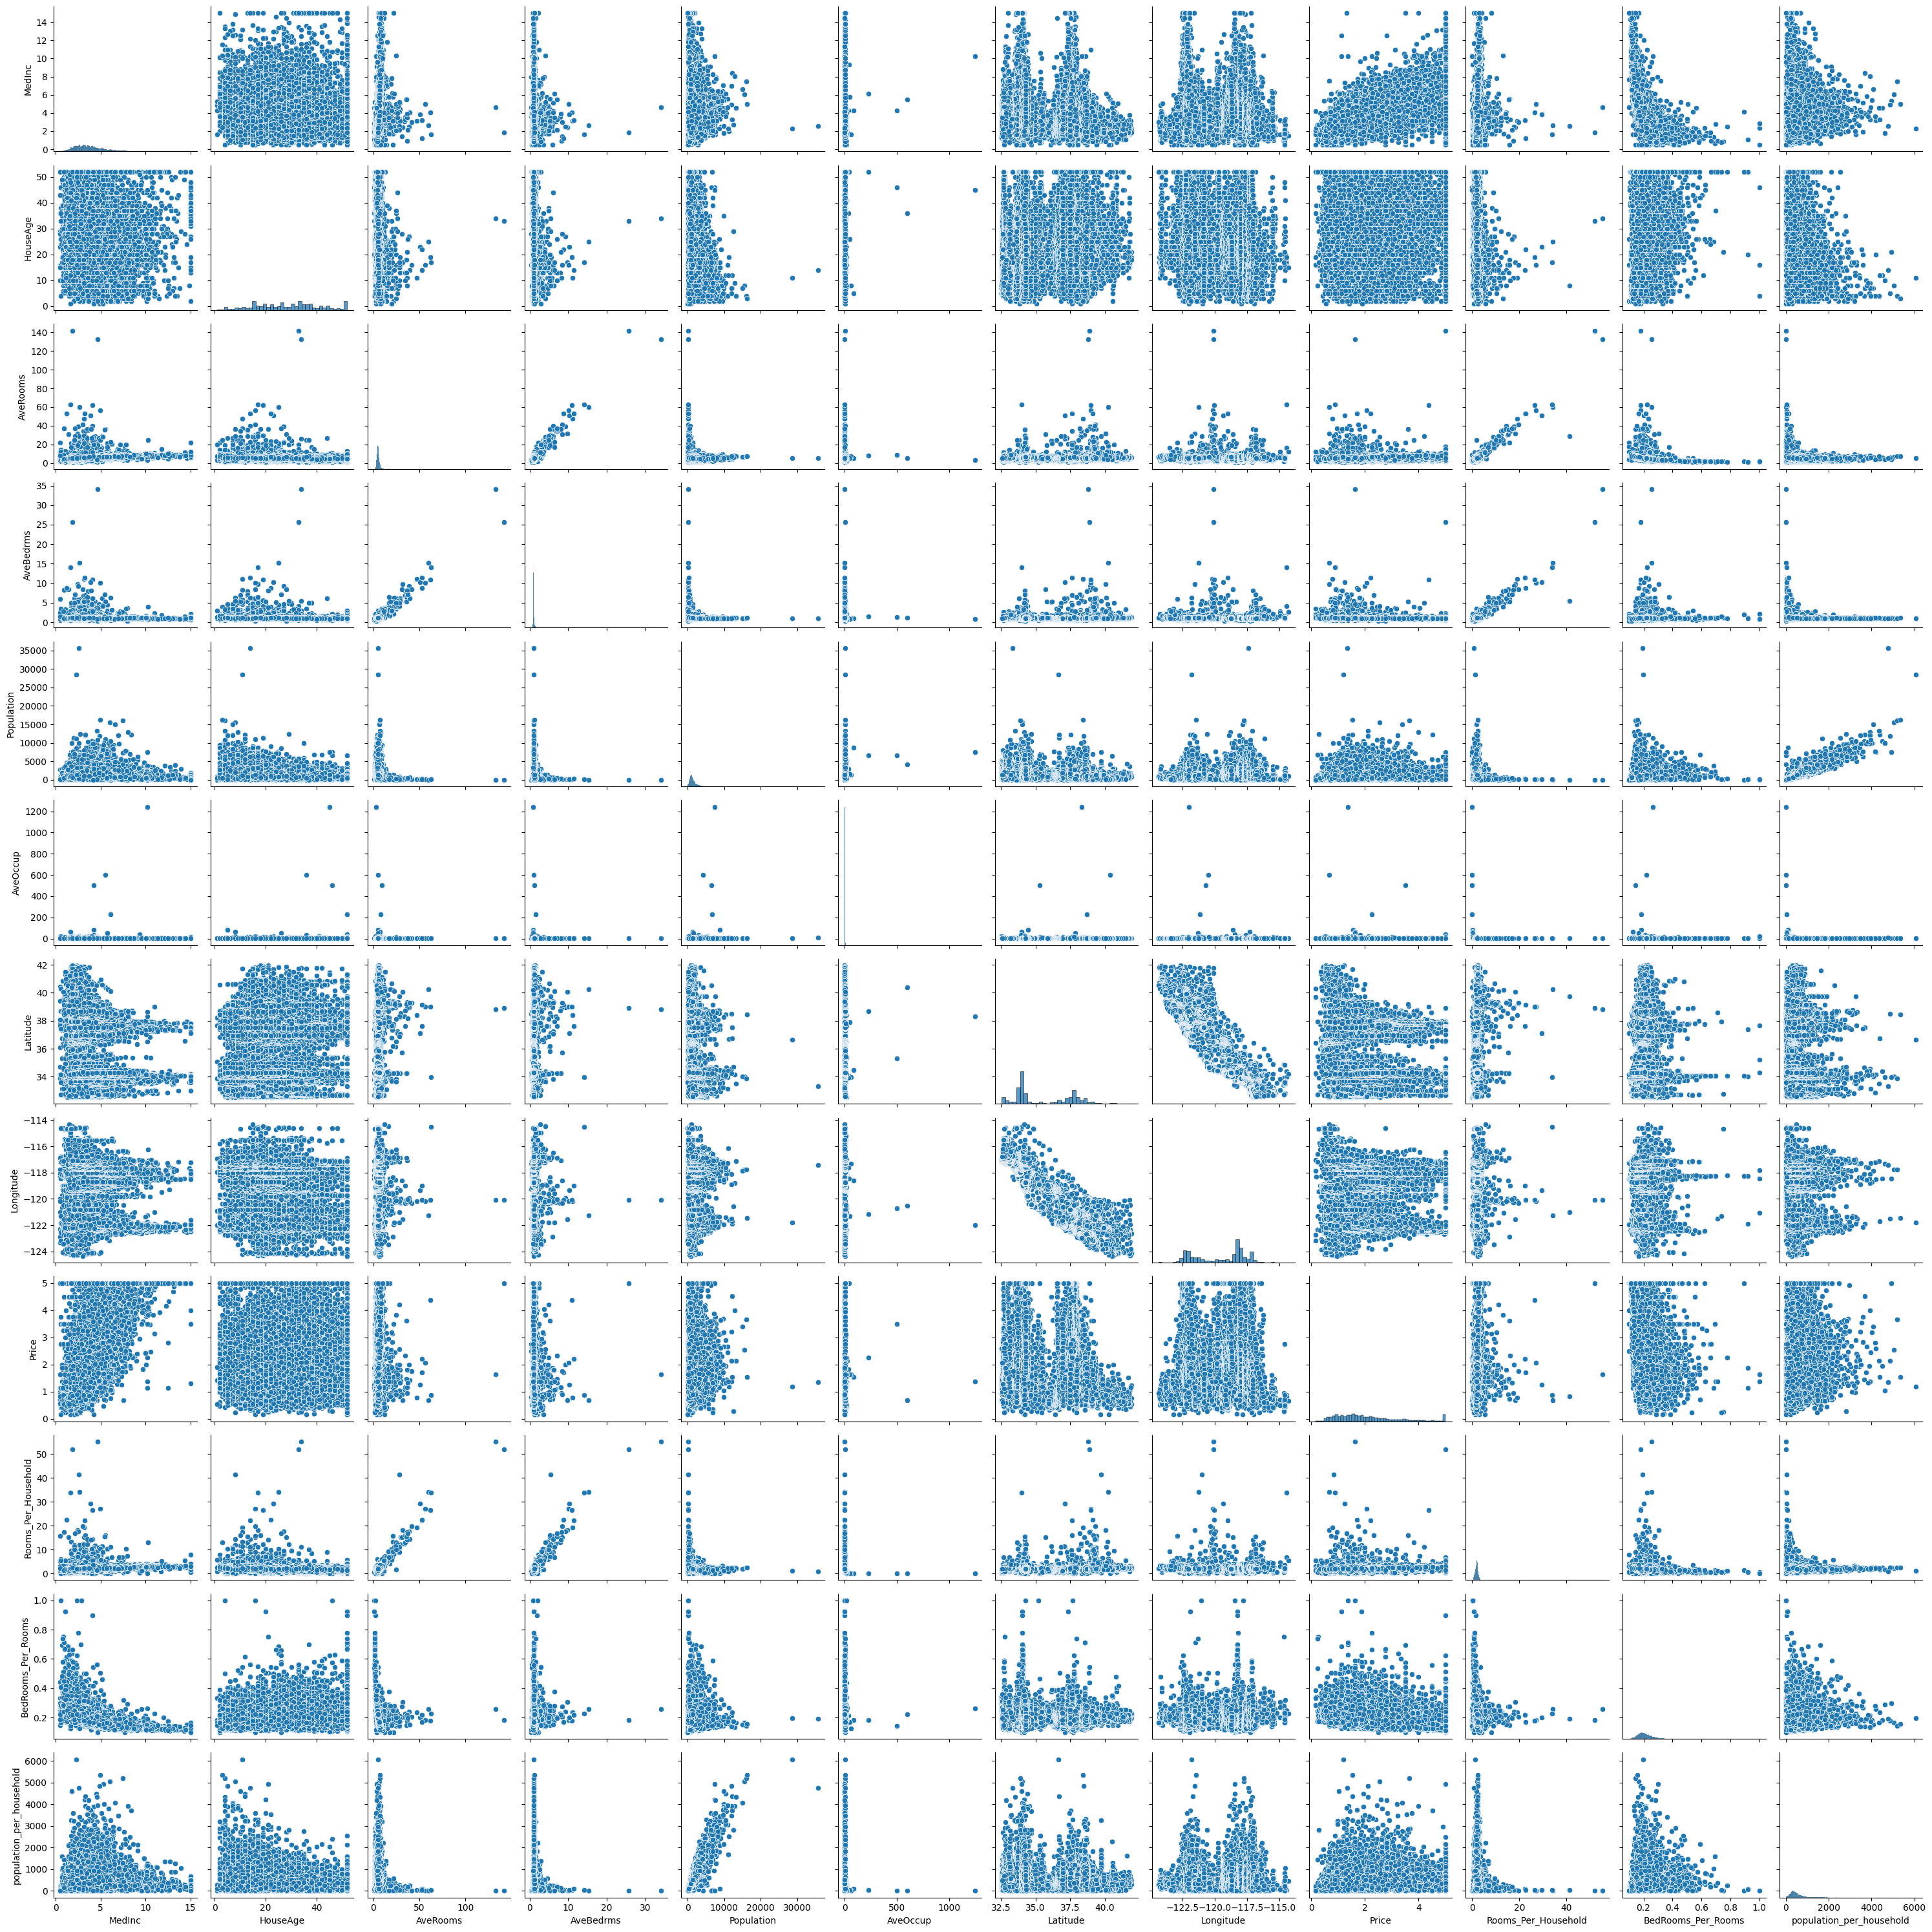

In [16]:
# Pair plot
sns.pairplot(df)
plt.tight_layout()
plt.show()

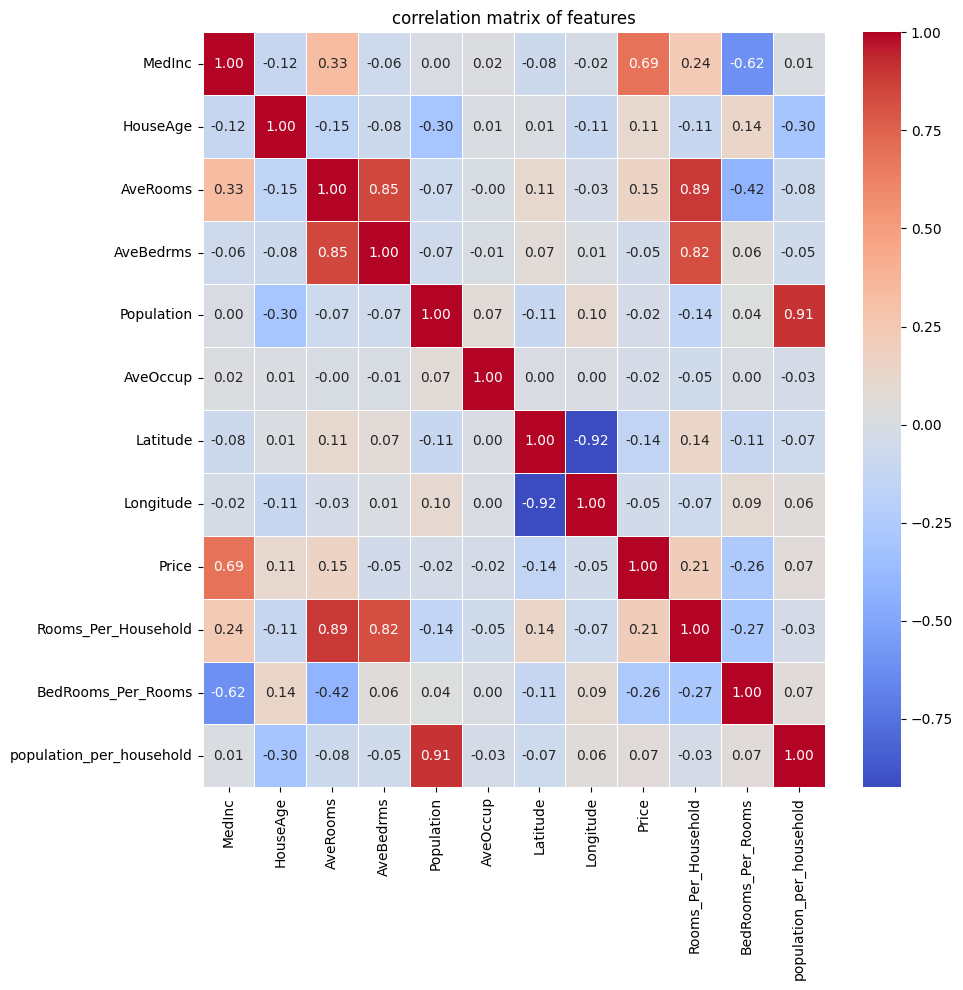

In [17]:
# ploting heatmap to see correlations 
plt.figure(figsize=(10,10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('correlation matrix of features')
plt.tight_layout()
plt.show()

## **step 5. Build & train ML models**

In [18]:
#independent features and dependent features 
x=df.drop(columns=['Price']) ## all features 
y=df['Price']# all targets(outputs)

print(f'features (x): {x.shape[1]} columns')
print(f'target (y):{y.shape}')

features (x): 11 columns
target (y):(20640,)


In [19]:
# train test my data 
# we will use 70% of data to train and 30% to test.

x_train, x_test, y_train, y_test=train_test_split(x,y,test_size=0.20,random_state=42)

In [20]:
# standerdizing the dataset
# bring all the features to same scale 
scaler=StandardScaler()# initialisiation
x_train_sc=scaler.fit_transform(x_train)
x_test_sc=scaler.transform(x_test)

print(f'Training set size : {x_train.shape[0]:,} samples')
print(f' Test    set size : {x_test.shape[0]:,} sample')


Training set size : 16,512 samples
 Test    set size : 4,128 sample


In [21]:
#---------model 1 . Linear Regression--------------
# Think of it as drawing a straight line that fits all the data points per
lr=LinearRegression()
lr.fit(x_train_sc,y_train)
print('👍Linear Regression trained!')

#model 2: ridge Regression
rid=Ridge()
rid.fit(x_train_sc,y_train)
print('👍ridge regression trained!')

rf_model=RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(x_train, y_train) #tree based model don't require scaled inputs 
print('👍RandomForest Regression trained!')



👍Linear Regression trained!
👍ridge regression trained!
👍RandomForest Regression trained!


## **step 6.Evaluate the models**

In [22]:
def evaluate_model(name , model, x_test_data,y_test_data):
    y_pred = model.predict(x_test_data)
    
    mae=mean_absolute_error(y_test_data,y_pred)
    mse=np.sqrt(mean_squared_error(y_test_data,y_pred))
  
    r2=r2_score(y_test_data,y_pred)
    print(f'\n{'='*50}')
    print(f'📌 {name}')
    print(f'{'='*50}')
    print(f'mean absolute error: {mae:.4f}')
    print(f'{'--'*30}')
    print(f'mean squared error: {mse:.4f}')
    print(f'{'--'*30}')
    print(f'R2 score: {r2:.4f}')
    print()
    print(f'{'**'*30}')

lr_report=evaluate_model('linear regression',lr,x_test_sc,y_test)
rid_report=evaluate_model('ridge regression',rid,x_test_sc,y_test)
rf_model_report=evaluate_model('randomforest regression',rf_model,x_test,y_test)



📌 linear regression
mean absolute error: 0.4874
------------------------------------------------------------
mean squared error: 0.6738
------------------------------------------------------------
R2 score: 0.6535

************************************************************

📌 ridge regression
mean absolute error: 0.4874
------------------------------------------------------------
mean squared error: 0.6738
------------------------------------------------------------
R2 score: 0.6535

************************************************************

📌 randomforest regression
mean absolute error: 0.3289
------------------------------------------------------------
mean squared error: 0.5050
------------------------------------------------------------
R2 score: 0.8054

************************************************************


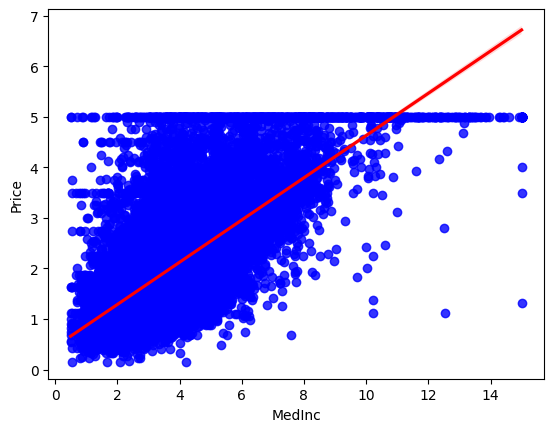

In [23]:
# regression plt : it draws the best fit line especially use for linear regression
sns.regplot(x="MedInc",y=y,data=df,scatter_kws={"color":"blue"},line_kws={"color":"red"})
plt.show()

## **hyperparameter tuning **

In [24]:

#1 Define parameter grid
parameter={
    'n_estimators':[100,200,300],
    'max_depth':[None,10,20,30],
    'min_samples_split':[2,5,10],
    'min_samples_leaf':[1,2,4],
    'max_features':['sqrt','log2',None]
    }

#2. set up RandomizedSearchCV
rf_random=RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=parameter,
    n_iter=15,   # tries 15 random combinations
    cv=3,        # 3-fold cross validation
    scoring='r2',
    random_state=42,
    n_jobs=-1    # use all available CPU cores
    )

In [26]:
print("Tuning hyperparameter......")
rf_random.fit(x_train,y_train)
best_rf_model=rf_random.best_estimator_  #cann't use _best_param_ because it is dictionary of hyperparameters not a fitted model   
                                          # best_estimators_ : already refit on full train data by default   
print("Best parameters found: ",best_rf_model)

Tuning hyperparameter......


c:\Users\nidhi\Documents\programming\python_programming\.venv\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best parameters found:  RandomForestRegressor(max_depth=20, max_features=None, min_samples_leaf=2,
                      n_estimators=200, n_jobs=-1, random_state=42)


In [30]:
# y_pred_tuned = best_rf.predict(x_test)
evaluate_model("Tunned random forest:",best_rf_model,x_test,y_test)


📌 Tunned random forest:
mean absolute error: 0.3284
------------------------------------------------------------
mean squared error: 0.5051
------------------------------------------------------------
R2 score: 0.8053

************************************************************


In [31]:
parameters={'alpha':[1,2,5,10,20,30,40,50,60,70,80,90]}
ridgecv=GridSearchCV(rid,parameters,scoring='neg_mean_squared_error',cv=5)
ridgecv.fit(x_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Ridge()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': [1, 2, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalu

In [32]:
ridge_pred=ridgecv.predict(x_test)



In [33]:
ridgecv.best_params_

{'alpha': 1}

In [34]:
ridgecv.best_score_

np.float64(-0.45548318433658164)

In [35]:
score=r2_score(y_test,ridge_pred)
score

0.6534017539994169